In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

In [2]:
zambia_int = pd.read_csv('../data/Zambia_International Linkages/international_link.csv')
lic_int = pd.read_csv('../data/LIC_InternationalLinkage/international_link.csv')

In [3]:
zambia_clean, zambia_lookup = clean_wb_wide(zambia_int, drop_top_rows=0)
lic_clean, lic_lookup = clean_wb_wide(lic_int, drop_top_rows=0)

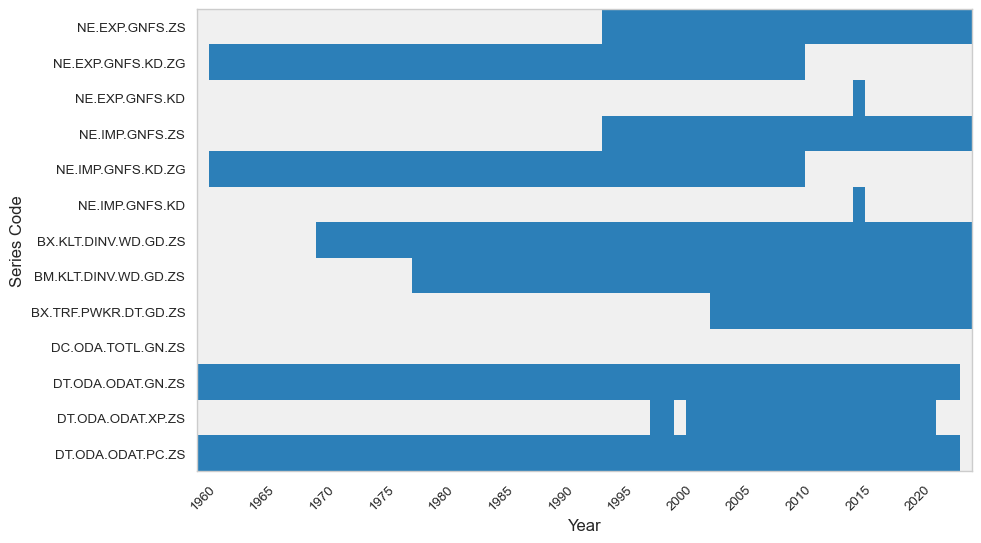

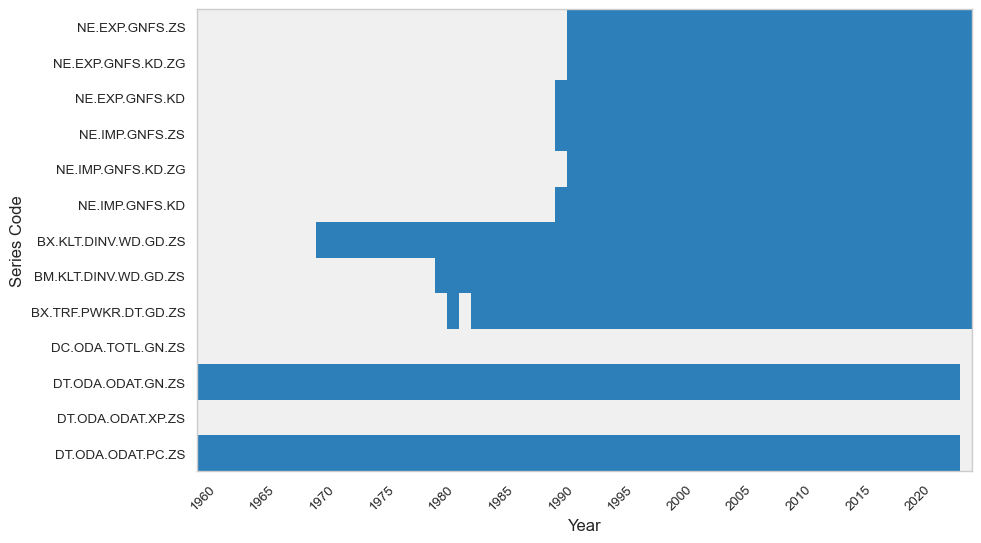

In [4]:
availability_zambia, fig_zambia, ax_zambia = plot_missing_heatmap(
    zambia_clean,
    lookup=zambia_lookup
)
availability_lic, fig_lic, ax_lic = plot_missing_heatmap(
    lic_clean,
    lookup=lic_lookup
)

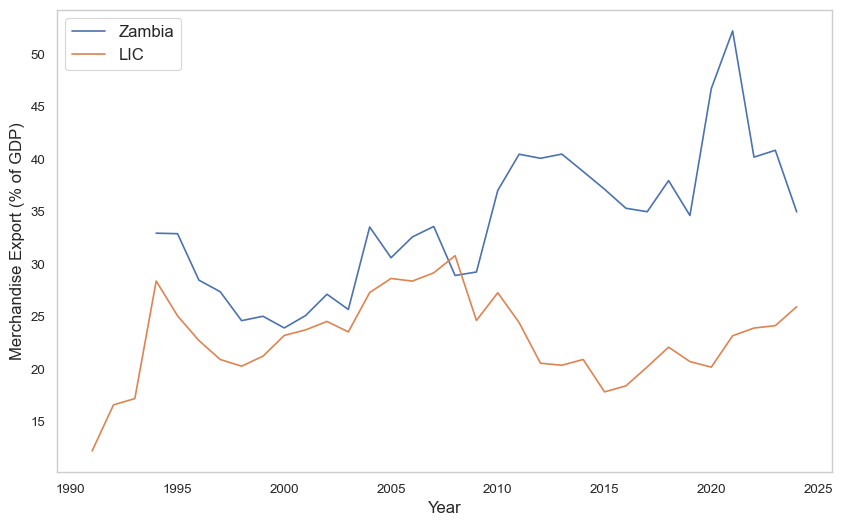

In [16]:
# merchandise exports and import (as percentage of GDP) NE.EXP.GNFS.ZS, NE.IMP.GNFS.ZS
# df = int_link_clean.dropna(subset=['NE.EXP.GNFS.ZS', 'NE.IMP.GNFS.ZS'])
df_zambia = zambia_clean.dropna(subset=['NE.EXP.GNFS.ZS', 'NE.IMP.GNFS.ZS'])
df_lic = lic_clean.dropna(subset=['NE.EXP.GNFS.ZS', 'NE.IMP.GNFS.ZS'])
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_zambia['Year'], df_zambia['NE.EXP.GNFS.ZS'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['NE.EXP.GNFS.ZS'], label='LIC')
# ax.plot(df_zambia['Year'], df_zambia['NE.IMP.GNFS.ZS'], label='Imports')
ax.legend(fontsize=12)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Merchandise Export (% of GDP)', fontsize=12)
ax.grid(False)

fig.savefig(
    "../figures/LIC/int_link/merchandise_export.pdf",
    format="pdf",
    bbox_inches="tight"
)

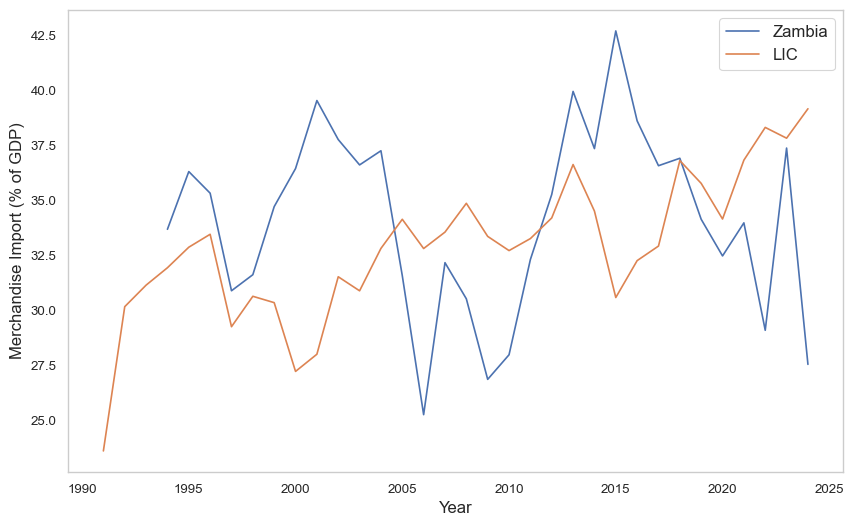

In [17]:
# import
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_zambia['Year'], df_zambia['NE.IMP.GNFS.ZS'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['NE.IMP.GNFS.ZS'], label='LIC')
ax.legend(fontsize=12)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Merchandise Import (% of GDP)', fontsize=12)
ax.grid(False)

fig.savefig(
    "../figures/LIC/int_link/merchandise_import.pdf",
    format="pdf",
    bbox_inches="tight"
)

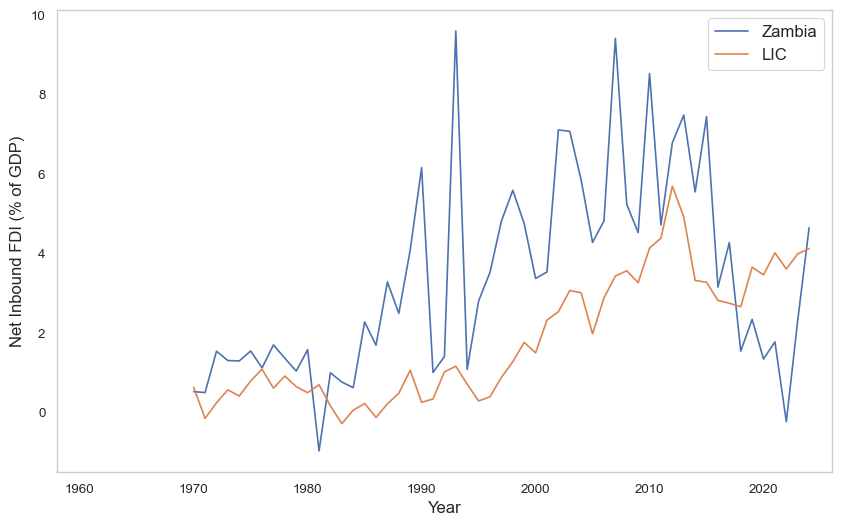

In [19]:
# Inbound FDI, net (percentage of GDP) BX.KLT.DINV.WD.GD.ZS (inflow)
# df = int_link_clean.dropna(subset=['BX.KLT.DINV.WD.GD.ZS'])
df_zambia = zambia_clean.dropna(subset=['BX.KLT.DINV.WD.GD.ZS'])
df_lic = lic_clean.dropna(subset=['BX.KLT.DINV.WD.GD.ZS'])

fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(df['Year'], df['BX.KLT.DINV.WD.GD.ZS'], marker='o')
ax.plot(df_zambia['Year'], df_zambia['BX.KLT.DINV.WD.GD.ZS'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['BX.KLT.DINV.WD.GD.ZS'], label='LIC')
ax.legend(fontsize=12)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Net Inbound FDI (% of GDP)', fontsize=12)

ax.set_xlim(1958, 2026)
ax.grid(False)

fig.savefig(
    "../figures/LIC/int_link/inbound_fdi_lic.pdf",
    format="pdf",
    bbox_inches="tight"
)

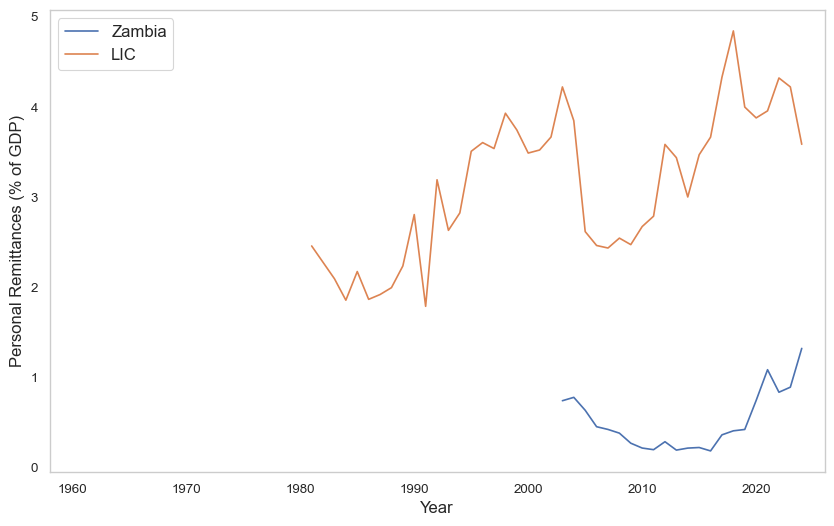

In [20]:
# Remittances (percentage of GDP) BX.TRF.PWKR.DT.GD.ZS
# df = int_link_clean.dropna(subset=['BX.TRF.PWKR.DT.GD.ZS'])
df_zambia = zambia_clean.dropna(subset=['BX.TRF.PWKR.DT.GD.ZS'])
df_lic = lic_clean.dropna(subset=['BX.TRF.PWKR.DT.GD.ZS'])
fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(df['Year'], df['BX.TRF.PWKR.DT.GD.ZS'], marker='o')

ax.plot(df_zambia['Year'], df_zambia['BX.TRF.PWKR.DT.GD.ZS'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['BX.TRF.PWKR.DT.GD.ZS'], label='LIC')
ax.legend(fontsize=12)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Personal Remittances (% of GDP)', fontsize=12)

ax.set_xlim(1958, 2026)
ax.grid(False)

fig.savefig(
    "../figures/LIC/int_link/remittances_lic.pdf",
    format="pdf",
    bbox_inches="tight"
)